In [2]:
import os
import shutil

# 1) Define repo URL and local directory name
REPO_URL = "https://github.com/semilleroCV/BreastCATT.git"
REPO_DIR = "BreastCATT"

# 2) Delete the directory if it exists
if os.path.isdir(REPO_DIR):
    print(f"Directory '{REPO_DIR}' exists. Deleting it...")
    shutil.rmtree(REPO_DIR)

# 3) Clone the repository
print(f"Cloning repository into ./{REPO_DIR}...")
os.system(f"git clone {REPO_URL}")

# 4) Change into the repo directory
os.chdir(REPO_DIR)
print("Current working directory:", os.getcwd())

Cloning repository into ./BreastCATT...


Cloning into 'BreastCATT'...


Current working directory: /kaggle/working/BreastCATT


In [17]:
!git fetch origin
!git pull origin main

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 382 bytes | 382.00 KiB/s, done.
From https://github.com/semilleroCV/BreastCATT
   4af7ad1..038da16  main       -> origin/main
From https://github.com/semilleroCV/BreastCATT
 * branch            main       -> FETCH_HEAD
Updating 4af7ad1..038da16
Fast-forward
 data/precompute_segmentation.py | 4 ++--
 1 file changed, 2 insertions(+), 2 deletions(-)


In [3]:
# every time you do a factory reset you have to run this
!pip install -r requirements.txt -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# log in hugging face hug to load data and models
from huggingface_hub import login

login(token="", add_to_git_credential=True)

Token has not been saved to git credential helper.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


# Precomputing text embeddings

In [6]:
!python data/precompute_embeddings.py --dataset_name SemilleroCV/BreastThermography --split test

Loading dataset and model...
2025-07-13 20:20:14.198287: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752438014.220275     201 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752438014.227127     201 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
README.md: 7.34kB [00:00, 20.2MB/s]
Generating test split: 100%|████████████| 72/72 [00:00<00:00, 480.52 examples/s]
Computing embeddings...
Map: 100%|██████████████████████████████| 72/72 [00:00<00:00, 128.06 examples/s]
Pushing new dataset to the Hub under config: with_embeddings
Map: 100%|██████████████████████████████| 72/72 [00:00<00:00, 998.87 examples/s]

Uploading the dataset shards: 100%|████████

# Verifying that stored embeddings are right

In [17]:
from datasets import load_dataset

dataset = load_dataset("SemilleroCV/DMR-IR", name="with_embeddings", trust_remote_code=True, split='train')

README.md: 0.00B [00:00, ?B/s]

train-00000-of-00014.parquet:   0%|          | 0.00/278M [00:00<?, ?B/s]

train-00001-of-00014.parquet:   0%|          | 0.00/275M [00:00<?, ?B/s]

train-00002-of-00014.parquet:   0%|          | 0.00/260M [00:00<?, ?B/s]

train-00003-of-00014.parquet:   0%|          | 0.00/275M [00:00<?, ?B/s]

...

test-00001-of-00004.parquet:   0%|          | 0.00/267M [00:00<?, ?B/s]

test-00002-of-00004.parquet:   0%|          | 0.00/264M [00:00<?, ?B/s]

test-00003-of-00004.parquet:   0%|          | 0.00/298M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5663 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1470 [00:00<?, ? examples/s]

## printing one example to verify later

In [19]:
print(dataset[0])

{'image': <PIL.TiffImagePlugin.TiffImageFile image mode=F size=640x480 at 0x7A8B3F830550>, 'label': 0, 'text': 'Patient is 75 years old of mestizo race. Has eating habits no fat. Complaints reported were no. Additionally, patient reported yes. No information provided for radiotherapy, use of hormone replacement. No protocol information provided.', 'text_embedding': [-0.22996659576892853, -0.020867105573415756, 0.14399594068527222, -0.21241213381290436, -0.9352342486381531, -0.1300118863582611, -0.8143057823181152, 0.06501231342554092, -0.9824453592300415, -0.09915896505117416, -0.9906427264213562, 0.0144188879057765, -0.07775440067052841, -0.06415258347988129, 0.9999222755432129, -0.05157077684998512, 0.1112450659275055, -0.17539362609386444, -0.8965616226196289, 0.3913998305797577, 0.04515006020665169, 0.9558783173561096, 0.04266832768917084, -0.9769684076309204, 0.2273259162902832, 0.10534391552209854, -0.15591350197792053, -0.010587803088128567, -0.9998792409896851, 0.98825764656066

In [9]:
print(dataset[10])

{'image': <PIL.TiffImagePlugin.TiffImageFile image mode=F size=320x240 at 0x7A8B3F8F22D0>, 'label': 0, 'text': 'Patient is 27 years old, weighs 62.0 kilograms, and is 157.5 centimeters tall. Regarding the protocol, a body temperature of 34.5 degrees Celsius.', 'text_embedding': [-0.09240838885307312, 0.24423329532146454, 0.20770297944545746, -0.009825156070291996, -0.9395618438720703, -0.2892228662967682, -0.8628329038619995, 0.06517961621284485, -0.9770727157592773, -0.14390379190444946, -0.9772132039070129, -0.04874299466609955, 0.2817443311214447, -0.04530727490782738, 0.9996523261070251, -0.0063527487218379974, 0.14296670258045197, 0.3306651711463928, -0.9437552690505981, -0.22251182794570923, 0.0663117915391922, 0.9342437982559204, -0.2129744589328766, -0.9787488579750061, 0.061707187443971634, 0.06840405613183975, -0.19453124701976776, -0.28293541073799133, -0.9998534917831421, 0.9765527248382568, -0.05590759962797165, -0.3888469934463501, -0.8935971260070801, 0.9999542236328125,

## loading the model

In [28]:
from transformers import AutoModel, AutoTokenizer
import torch

lm_name = "UFNLP/gatortron-base"
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(lm_name)
language_model = AutoModel.from_pretrained(lm_name).to(device)
language_model.eval() # Set to evaluation mode

2025-07-10 14:40:49.225349: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752158449.247878      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752158449.254814      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


MegatronBertModel(
  (embeddings): MegatronBertEmbeddings(
    (word_embeddings): Embedding(50176, 1024, padding_idx=0)
    (position_embeddings): Embedding(512, 1024)
    (token_type_embeddings): Embedding(2, 1024)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): MegatronBertEncoder(
    (layer): ModuleList(
      (0-23): 24 x MegatronBertLayer(
        (attention): MegatronBertAttention(
          (ln): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
          (self): MegatronBertSelfAttention(
            (query): Linear(in_features=1024, out_features=1024, bias=True)
            (key): Linear(in_features=1024, out_features=1024, bias=True)
            (value): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): MegatronBertSelfOutput(
            (dense): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
  

## forwarding a printing model's outputs

In [36]:
prompt = dataset[10]['text']  # Get the prompt text

print(prompt)

with torch.no_grad():
  inputs = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True).to(device)
  outputs = language_model(**inputs)
  # Assume model returns a 'pooler_output' attribute containing the embeddings
  features = outputs.pooler_output

print(features)

Patient is 27 years old, weighs 62.0 kilograms, and is 157.5 centimeters tall. Regarding the protocol, a body temperature of 34.5 degrees Celsius.
tensor([[-0.0924,  0.2442,  0.2077,  ..., -0.1454, -0.2519, -0.1748]],
       device='cuda:0')


# Precomputing segmentation outputs

In [5]:
!python data/precompute_segmentation.py --dataset_name SemilleroCV/DMR-IR --split train

Using device: cuda
Loading segmentation model...
📥 Downloading TransUNet weights from Hugging Face Hub (SemilleroCV/transunet-breast-cancer)...
lucky-sweep-6_0.4937.pth: 100%|██████████████| 421M/421M [00:12<00:00, 33.9MB/s]

✅ Successfully downloaded TransUNet weights to: checkpoints/segmentation/lucky-sweep-6_0.4937.pth
Loading dataset: SemilleroCV/DMR-IR
README.md: 6.86kB [00:00, 17.8MB/s]
train-00000-of-00014.parquet: 100%|███████████| 278M/278M [00:02<00:00, 136MB/s]
train-00001-of-00014.parquet: 100%|███████████| 275M/275M [00:01<00:00, 153MB/s]
train-00002-of-00014.parquet: 100%|███████████| 260M/260M [00:01<00:00, 151MB/s]
train-00003-of-00014.parquet: 100%|███████████| 275M/275M [00:01<00:00, 145MB/s]
train-00004-of-00014.parquet: 100%|███████████| 288M/288M [00:01<00:00, 151MB/s]
train-00005-of-00014.parquet: 100%|███████████| 293M/293M [00:02<00:00, 136MB/s]
train-00006-of-00014.parquet: 100%|███████████| 292M/292M [00:01<00:00, 148MB/s]
train-00007-of-00014.parquet: 100%|██

In [6]:
!python data/precompute_segmentation.py --dataset_name SemilleroCV/DMR-IR --split test

Using device: cuda
Loading segmentation model...
✅ TransUNet weights already exist at: checkpoints/segmentation/lucky-sweep-6_0.4937.pth
Loading dataset: SemilleroCV/DMR-IR
README.md: 7.49kB [00:00, 21.6MB/s]
Generating test split: 100%|█████████| 1470/1470 [00:16<00:00, 86.78 examples/s]
Computing segmentation masks...
Generating segmentation masks: 100%|█| 1470/1470 [00:25<00:00, 57.31 examples/s]
Pushing new dataset to the Hub under config: with_embeddings_and_segmentation
Map: 100%|████████████████████████████| 368/368 [00:01<00:00, 216.46 examples/s]

Map: 100%|████████████████████████████| 368/368 [00:01<00:00, 235.97 examples/s]

Map: 100%|████████████████████████████| 367/367 [00:01<00:00, 238.59 examples/s]

Map: 100%|████████████████████████████| 367/367 [00:01<00:00, 233.83 examples/s]

Uploading the dataset shards: 100%|███████████████| 4/4 [01:07<00:00, 16.87s/it]
Done!


## verify segmentations

In [7]:
from datasets import load_dataset

dataset = load_dataset("SemilleroCV/BreastThermography", name="with_embeddings_and_segmentation", trust_remote_code=True, split='train')

README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/52.1M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/13.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/285 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/72 [00:00<?, ? examples/s]

In [16]:
import numpy as np

sample = dataset[0]
mask = np.array(sample['segmentation_mask'])
print(mask.shape)

(1, 224, 224)


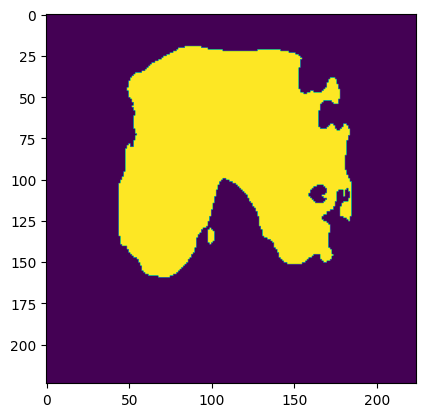

In [18]:
import matplotlib.pyplot as plt

plt.imshow(mask.squeeze(0))

In [21]:
def plot_many_masks(dataset, num_images=25, cols=5):
    rows = (num_images + cols - 1) // cols  # Compute required rows
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

    for i in range(num_images):
        sample = dataset[i]
        mask = np.array(sample['segmentation_mask']).squeeze()

        ax = axes[i // cols, i % cols] if rows > 1 else axes[i % cols]
        ax.imshow(mask, cmap='gray')
        ax.set_title(f"Image {i}")
        ax.axis('off')

    # Hide unused subplots (if num_images doesn't fill the grid)
    for j in range(num_images, rows * cols):
        ax = axes[j // cols, j % cols] if rows > 1 else axes[j % cols]
        ax.axis('off')

    plt.tight_layout()
    plt.show()

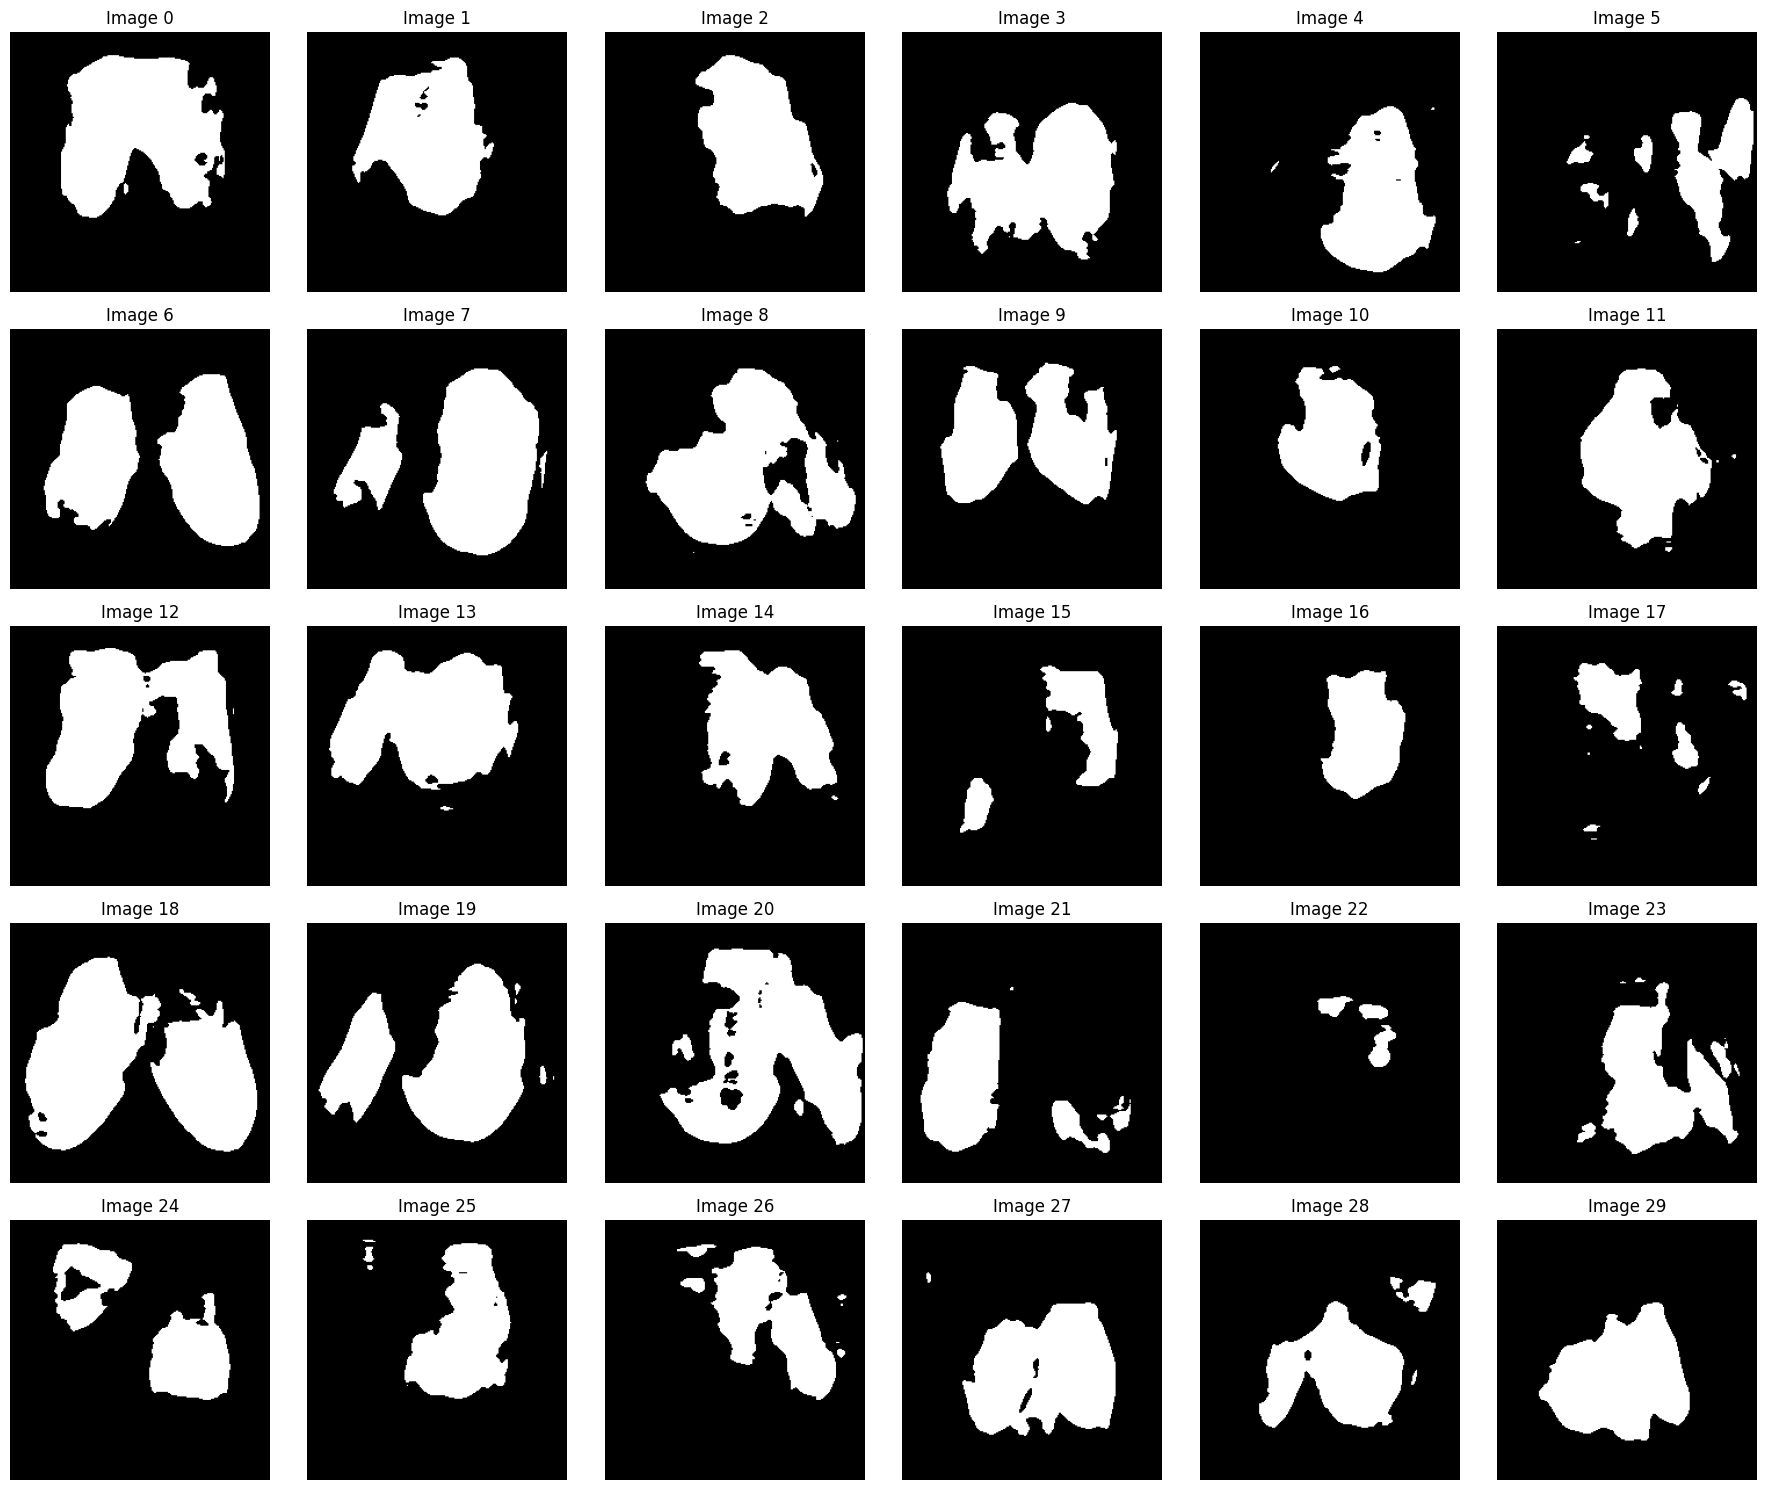

In [22]:
plot_many_masks(dataset, num_images=30, cols=6)